            Date         Open         High          Low        Close  \
0     2004-08-19    50.050049    52.082081    48.028027    50.220219   
1     2004-08-20    50.555557    54.594597    50.300301    54.209209   
2     2004-08-23    55.430431    56.796799    54.579578    54.754753   
3     2004-08-24    55.675674    55.855858    51.836838    52.487488   
4     2004-08-25    52.532532    54.054054    51.991993    53.053055   
...          ...          ...          ...          ...          ...   
4426  2022-03-18  2668.489990  2724.879883  2645.169922  2722.510010   
4427  2022-03-21  2723.270020  2741.000000  2681.850098  2722.030029   
4428  2022-03-22  2722.030029  2821.000000  2722.030029  2797.360107   
4429  2022-03-23  2774.050049  2791.770020  2756.699951  2765.510010   
4430  2022-03-24  2784.000000  2832.379883  2755.010010  2831.439941   

        Adj Close    Volume  
0       50.220219  44659096  
1       54.209209  22834343  
2       54.754753  18256126  
3       52.4874

C:\Users\adity\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 35s 231ms/step - loss: 0.0023 - val_loss: 0.1964
Epoch 2/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 22s 208ms/step - loss: 0.0016 - val_loss: 0.0815
Epoch 3/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 230ms/step - loss: 9.8172e-04 - val_loss: 0.0440
Epoch 4/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 22s 204ms/step - loss: 0.0012 - val_loss: 0.0217
Epoch 5/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 231ms/step - loss: 0.0016 - val_loss: 0.0119
Epoch 6/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 26s 236ms/step - loss: 9.7104e-04 - val_loss: 0.0035
Epoch 7/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 230ms/step - loss: 0.0015 - val_loss: 0.0050
Epoch 8/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 27s 254ms/step - loss: 8.4952e-04 - val_loss: 0.0067
Epoch 9/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 232ms/step - loss: 9.1808e-04 - val_loss: 0.0062
Epoch 10/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 27s 246ms/step - loss: 7.8421e-04 - val_loss: 0.0071
Epoch 11/18
108/108 ━━━━━━━━━━━━━━━━━━━━ 23s 217ms/step - loss: 7.3181e-04 - val_loss: 0.

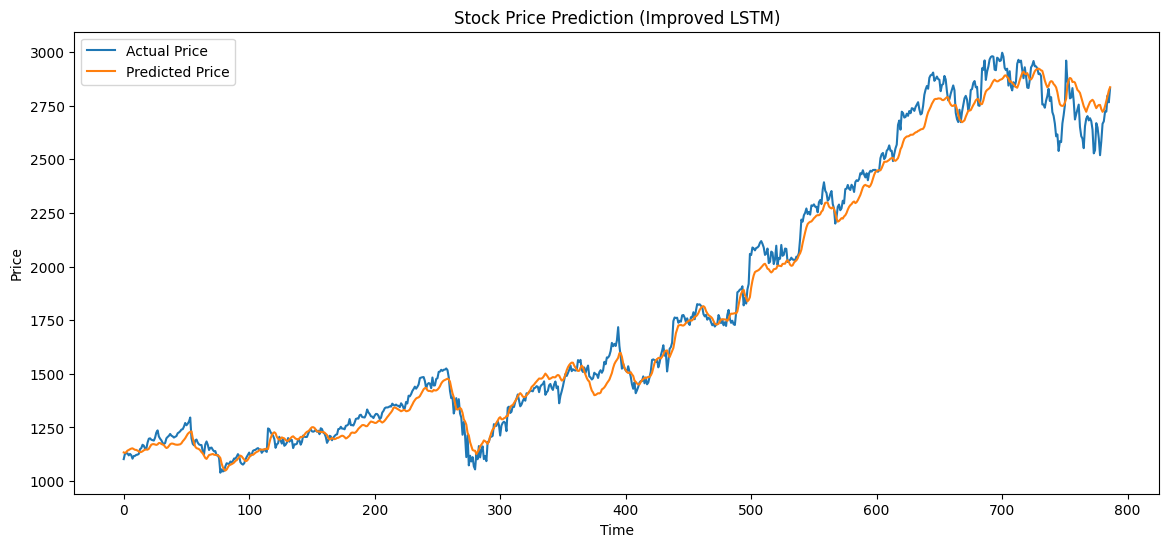

In [2]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_csv("GOOGL.csv")

# IMPORTANT: Sort by date
df = df.sort_values('Date')

print(df)

# Keep required columns
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

# ==============================
# 3. TRAIN-TEST SPLIT
# ==============================
train_size = int(len(df) * 0.8)
train_data = df[:train_size]
test_data = df[train_size:]

# ==============================
# 4. SCALING
# ==============================
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# ==============================
# 5. CREATE SEQUENCES
# ==============================
def create_dataset(data, time_step=100):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i])
        y.append(data[i, 3])  # Predict "Close"
    return np.array(X), np.array(y)

time_step = 100

X_train, y_train = create_dataset(train_scaled, time_step)
X_test, y_test = create_dataset(test_scaled, time_step)

# ==============================
# 6. BUILD MODEL (IMPROVED)
# ==============================
model = Sequential()

model.add(Bidirectional(LSTM(100, return_sequences=True),
                        input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(Bidirectional(LSTM(100)))
model.add(Dropout(0.2))

# NEW Dense layer for better learning
model.add(Dense(25, activation='relu'))
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# ==============================
# 7. EARLY STOPPING
# ==============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

# ==============================
# 8. TRAIN MODEL
# ==============================
history = model.fit(
    X_train, y_train,
    epochs=18,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    shuffle=False,   # IMPORTANT for time series
    verbose=1
)

# ==============================
# 9. PREDICTIONS
# ==============================
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# ==============================
# 10. INVERSE SCALING
# ==============================
def inverse_transform(pred, data):
    temp = np.zeros((len(pred), data.shape[1]))
    temp[:, 3] = pred[:, 0]  # Close column
    return scaler.inverse_transform(temp)[:, 3]

train_pred_actual = inverse_transform(train_pred, train_scaled)
y_train_actual = inverse_transform(y_train.reshape(-1, 1), train_scaled)

test_pred_actual = inverse_transform(test_pred, test_scaled)
y_test_actual = inverse_transform(y_test.reshape(-1, 1), test_scaled)

# ==============================
# 11. RMSE
# ==============================
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_pred_actual))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred_actual))

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

# ==============================
# 12. PLOT
# ==============================
plt.figure(figsize=(14,6))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(test_pred_actual, label="Predicted Price")

plt.title("Stock Price Prediction (Improved LSTM)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()